# Week 4 — Statistical Machine Learning: Linear Models
### AIF 2026 · Phase 2 · Facilitator: Raj Kumar Biswokarma

---

## Session Roadmap

| Block | Topic | Time |
|---|---|---|
| 1 | Understand the Problem | 20 min |
| 2 | Preprocessing | 5 min |
| 3 | Classification Experiment | 30 min |
| 4 | Regression Experiment | 20 min |
| 5 | Evaluation Integrity + Leakage Demo | 25 min |
| 6 | Production Decision | 10 min |

---

## Business Context

You are a Data Scientist at a telecom company. The business is losing customers to churn. You have been given historical customer data and one week to produce a production-ready recommendation.

**There is no prescribed model. You decide — and you must defend that decision with evidence.**

**Dataset:** Telco Customer Churn — https://www.kaggle.com/datasets/blastchar/telco-customer-churn  
Single CSV · 7043 rows · 21 columns · Target: `Churn` (Yes/No)

---

## Important Note
This is a guided notebook. You are expected to:
- Think critically before writing any code
- Make decisions and justify them in writing
- Explore different approaches and compare results
- Fill in all written response sections


In [1]:
# your code here
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

sns.set_theme(style="darkgrid", context="talk")


#data loading
df = pd.read_csv("../data/telecom_churn.csv")


---

# Block 1 — Understand the Problem First

---

## What Is an ML Problem?

Before touching any model, you need to formulate the problem formally. Every ML problem has the same components:

| Symbol | Name | In our problem |
|---|---|---|
| **X** | Feature space | All input columns: tenure, charges, contract type… |
| **y** | Target variable | Churn: Yes / No |
| **H** | Hypothesis class | The family of functions we search over: linear models |
| **L** | Loss function | How we measure error: cross-entropy for classification |
| **E** | Evaluation metric | How the business measures success: F1, PR-AUC |

**Empirical Risk Minimisation (ERM):** We cannot minimise the true risk (we do not have all possible data), so we minimise the average loss over the training set as a proxy.

$$\hat{\theta} = \arg\min_{\theta} \frac{1}{n} \sum_{i=1}^{n} L(y_i, f_\theta(x_i))$$

---

## Probability Distributions in ML

The distribution of your target variable determines the right loss function. This is not arbitrary.

| Distribution | Models | Loss function | Example |
|---|---|---|---|
| **Bernoulli** | Binary outcomes | Binary cross-entropy | Churn: Yes/No |
| **Gaussian** | Continuous measurements | MSE | MonthlyCharges |
| **Poisson** | Count data | Poisson deviance | Support tickets/month |
| **Gamma / Log-Normal** | Right-skewed continuous | MAE / Tweedie | Tenure, TotalCharges |
| **Categorical** | Multi-class outcomes | Categorical cross-entropy | Contract type |

**Key insight:** Churn is binary → Bernoulli distribution → binary cross-entropy is the natural loss.

---

## Sources of Uncertainty

Training data is a finite, imperfect sample of the real world. Before modelling, identify where the data might fail you:

- **Sampling noise** — 7,043 customers is a sample. The true population may behave differently.
- **Label noise** — Was churn recorded correctly? Cancelled but re-subscribed? Edge cases.
- **Missing data** — `TotalCharges` has whitespace nulls. Why? Random or systematic?
- **Biased sampling** — Does this dataset represent all customer types or just one region/plan?
- **Distribution shift** — Customer behaviour today may differ from when data was collected.
- **Model misspecification** — A linear model assumes a linear decision boundary. Is that true?

---

## 1.1 Basic Inspection

### Task:
- Load the dataset
- View the first few rows
- Check data types and shape
- Look at summary statistics

### Questions:
- What does each row represent?
- Are the data types appropriate for each column?
- Is `TotalCharges` the dtype you expect?

### Hint:
- Use `.head()`, `.info()`, `.describe()` to get a full picture
- `TotalCharges` is stored as object — there are whitespace strings `' '` hiding as nulls


In [2]:
# your code here
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# your code here
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
# changing dtype of TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce') 
#coerce will convert non-numeric values to NaN

print(df['TotalCharges'].isnull().sum()) #created 11 null values

11


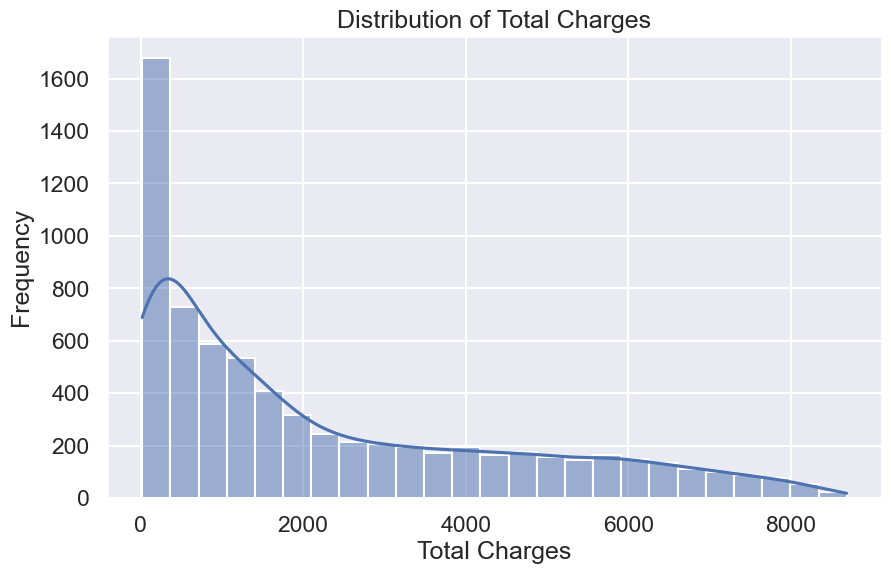

In [5]:
fig = plt.figure(figsize=(10, 6))
sns.histplot(df['TotalCharges'], kde=True)
plt.title('Distribution of Total Charges')
plt.xlabel('Total Charges')
plt.ylabel('Frequency')
plt.show()

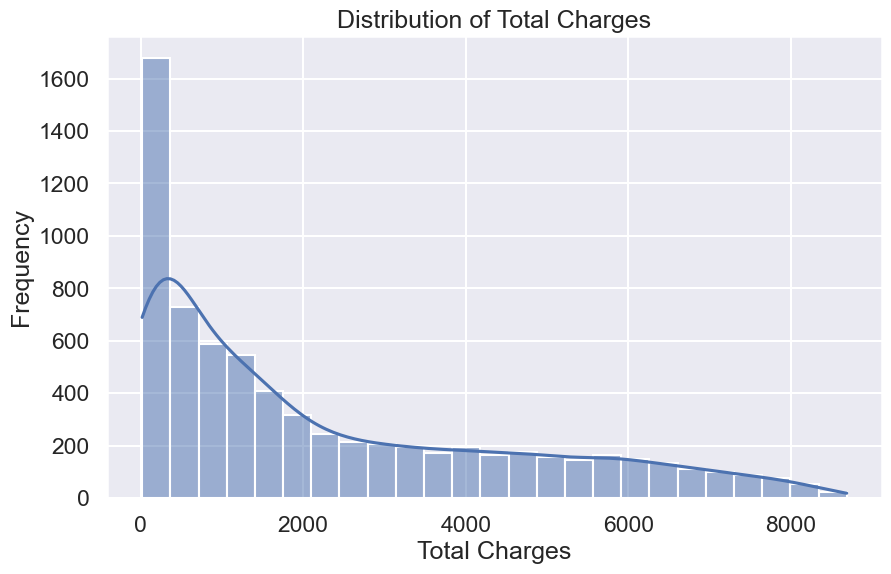

In [6]:
# impute TotalCharges correctly after converting to numeric
# ensure TotalCharges is numeric (previous cell used to_numeric)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# fill NaNs with median (don't use inplace assignment to a variable)
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# plot distribution
fig = plt.figure(figsize=(10, 6))
sns.histplot(df['TotalCharges'], kde=True)
plt.title('Distribution of Total Charges')
plt.xlabel('Total Charges')
plt.ylabel('Frequency')
plt.show()

In [7]:
# your code here
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928
std,0.368612,24.559481,30.090047,2265.270398
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [8]:
df['TotalCharges'].isnull().sum()

np.int64(0)

## Answers
1. Each row represents a customer
2. No, I expected TotalCharges to be numeric value i.e. float; however, the data has labeled it as string which i need to change.
3. No, I didn't expect 

---

## 1.2 Problem Formulation

### Task:
Write out the ML problem formally using the structure below.

### Questions:
- What is X (your feature space)?
- What is y (your target variable)?
- What probability distribution naturally models the target? What does that tell you about the right loss function?
- What is your hypothesis class (model family)?
- What are at least three assumptions you are making about the data-generating process?
- Where could this data be noisy, biased, or incomplete?

### Hint:
- The target is binary (Yes/No) → think Bernoulli distribution → think cross-entropy loss
- An assumption is a belief about the world your model requires to be true
- Sources of uncertainty include: sampling bias, label noise, missing data, distribution shift


**Your formulation here:**

- X (feature space): Since our target variable is churn, anything beside churn and customerId, which we probably don't need, are our feature space.
- y (target variable): Churn
- Probability distribution of y: Bernoulli distribution
- Natural loss function: Cross The target variable in the Telco Customer Churn dataset is binary, taking values of either 0 (No Churn) or 1 (Churn). Therefore, it is naturally modeled by a Bernoulli distribution, where p represents the probability of a customer churning. Since the Bernoulli distribution underlies binary classification problems, the appropriate loss function is Binary Cross-Entropy (Log Loss), which measures the difference between the predicted probabilities and the actual outcomes. This loss function is derived from the negative log-likelihood of the Bernoulli distribution and is therefore more suitable than Mean Squared Error for churn prediction. 
- Hypothesis class: Logistic Regression
- Assumption 1: The relationship between target variable (Churn) and other features are approximately normal
- Assumption 2: Customers are independent of eachother
- Assumption 3: Feature contain enough data to explain customer churn behavior
- Sources of uncertainty: 
    * Missing or imperfect data values
    * Customer behavior may be influenced by factors not included in the dataset.
    * Future customer behavior may differ from historical patterns.
    * The target variable is moderately imbalanced (approximately 72% non-churn and 28% churn), which may bias the model toward predicting the majority class.
    * Random variation in customer decisions that cannot be fully captured by the available features.

In [9]:
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

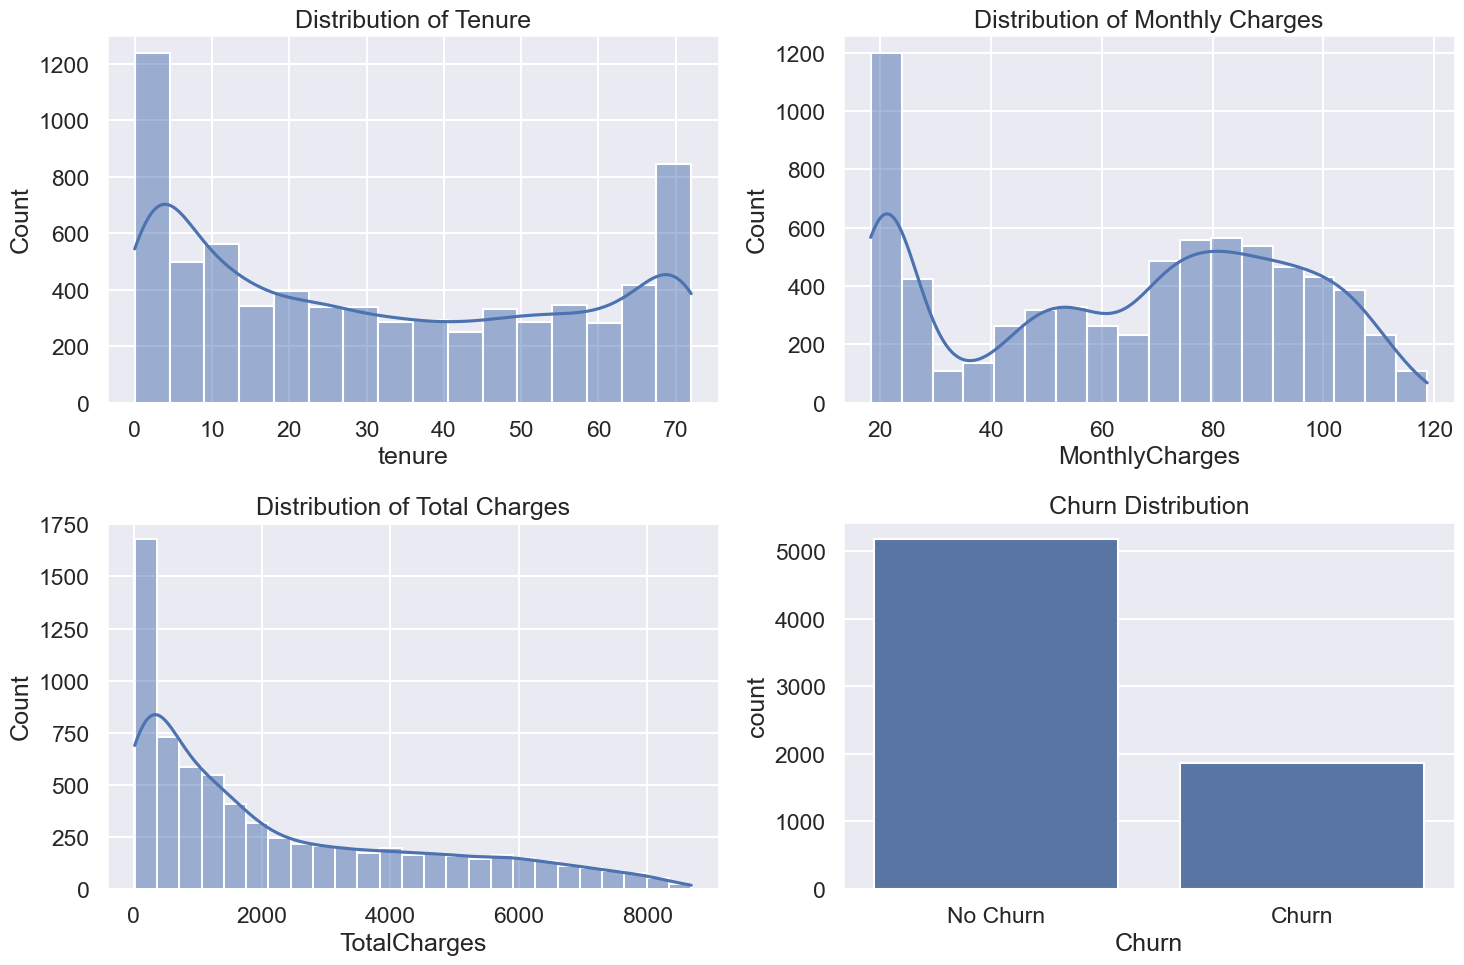

In [10]:
fig, ax = plt.subplots(2, 2, figsize=(15, 10))

sns.histplot(df['tenure'], kde=True, ax=ax[0, 0])
ax[0, 0].set_title('Distribution of Tenure')
sns.histplot(df['MonthlyCharges'], kde=True, ax=ax[0, 1])
ax[0, 1].set_title('Distribution of Monthly Charges')
sns.histplot(df['TotalCharges'], kde=True, ax=ax[1, 0])
ax[1, 0].set_title('Distribution of Total Charges')
sns.countplot(x='Churn', data=df, ax=ax[1, 1])
ax[1, 1].set_title('Churn Distribution')
ax[1, 1].set_xticklabels(['No Churn', 'Churn'])
plt.tight_layout()
plt.show()


---

## 1.3 Data Profiling & Fixing

### Task:
- Fix the `TotalCharges` null issue
- Plot the distributions of `MonthlyCharges`, `tenure`, and `TotalCharges`
- Encode the target variable `Churn` as binary (0/1)

### Questions:
- What distribution does `MonthlyCharges` follow? `tenure`? `TotalCharges`?
- Why does `TotalCharges` contain nulls even though it looks numeric?
- Are there impossible or suspicious values in any column?

### Hint:
- `pd.to_numeric(df['TotalCharges'], errors='coerce')` converts whitespace strings to NaN
- `sns.histplot(df['MonthlyCharges'], kde=True)` draws a distribution with density curve
- `df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})`

### Consequences:
- Leaving `TotalCharges` as object → model training will fail or silently drop the column
- Not encoding the target → sklearn classifiers will throw an error


## Answers
1. TotaCharges follows Possion Distribution. Tenure follows Bi-Modal Distribution. MonthlyCharges follows Multimodal distribution.

2. Because of the whitespace the data contains. When we transform totalcharges from str to numeric value, the white space changed into NaN/


In [11]:
# your code here
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928
std,0.368612,24.559481,30.090047,2265.270398
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [12]:
# your code here
for col in df.select_dtypes(include='object'):
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False))


customerID
customerID
7590-VHVEG    1
5575-GNVDE    1
3668-QPYBK    1
7795-CFOCW    1
9237-HQITU    1
             ..
6840-RESVB    1
2234-XADUH    1
4801-JZAZL    1
8361-LTMKD    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64

gender
gender
Male      3555
Female    3488
Name: count, dtype: int64

Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

OnlineSecurity
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

OnlineBackup
OnlineBackup
No                     3088
Yes                    2429


In [13]:
# your code here
df['customerID'].nunique()

7043

---

## The Accuracy Trap

The dataset has ~27% churn. This is **imbalanced**. Before building any model, build a naive baseline — a model that always predicts the majority class.

**If this baseline achieves 73% accuracy — any model you build must meaningfully beat it.**

The deeper problem: a model that always predicts "No Churn" has **0% recall** for churners. It catches no one. It is completely useless to the business — yet reports 73% accuracy.

**This is why accuracy is not your primary metric here.**

---

## 1.4 The Naive Baseline

### Task:
Build a model that always predicts the majority class (No Churn). Evaluate its accuracy, recall, and F1.

### Questions:
- What accuracy does the naive baseline achieve?
- What is the class distribution in the dataset?
- Why is a model that achieves this accuracy potentially worthless?

### Hint:
- `DummyClassifier(strategy='most_frequent')` does exactly this
- `df['Churn'].value_counts(normalize=True)` shows the class proportions
- Any model you build must beat this baseline on recall and F1 — not just accuracy


## Answers
1. Naive Baseline achieves 73.52% accuracy score
2. The target variable (Churn) is moderately imbalanced. Approximately 73.46% of customers belong to the "No Churn" class, while 26.54% belong to the "Churn" class. This imbalance may cause models to favor the majority class, making evaluation metrics such as Recall, F1-score, and ROC-AUC more informative than accuracy alone.
3. Since the target variable is imbalanced (approximately 73% "No Churn" and 27% "Churn"), machine learning models may become biased toward the majority class. As a result, the model may predict "No Churn" more frequently than "Churn", leading to high accuracy but poor detection of actual churners.

In [14]:
# your code here
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier

X = df.drop(columns=['customerID', 'Churn'])
y = df['Churn'].map({'No': 0, 'Yes': 1})  # Encode target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)

y_pred = dummy.predict(X_test)
print("Accuracy:", dummy.score(X_test, y_test))



Accuracy: 0.7352732434350603


---

## 💬 Discussion

> **Your manager sees 73% accuracy and is thrilled. Should they be? What is the first question you ask?**

---

# Block 2 — Preprocessing

Preprocessing was covered in Week 1. We keep this block minimal — working code only.

---

## 2.1 Encode, Split, Scale

### Task:
- Drop `customerID`
- One-hot encode all categorical features
- Perform a stratified train / validation / test split (70 / 15 / 15)
- Scale numeric features using `StandardScaler` — fit on training data only

### Questions:
- Why do we use stratified splitting for a churn dataset?
- Why do we fit the scaler on training data only?
- What would happen if we scaled before splitting?

### Hint:
- `pd.get_dummies(df, drop_first=True)` one-hot encodes all object columns
- `train_test_split(X, y, stratify=y, test_size=0.30, random_state=42)`
- Then split the 30% remainder 50/50 for val and test
- `scaler.fit(X_train)` → `scaler.transform(X_train)`, `scaler.transform(X_val)`, `scaler.transform(X_test)`

### Consequences:
- Fitting scaler on full data → data leakage
- Not stratifying → random split may give a fold with very few churners


## Answers

1. To preserve the original churn/non-churn ratio in all data splits. To prevent information from validation and test sets influencing the model.
2. Scaling is used to bring features to a similar range so that variables with large numerical values do not dominate variables with smaller values.
3. Data leakage occurs, leading to overly optimistic evaluation results.



In [15]:
# your code here
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df.drop(columns=['customerID', 'Churn'])
y = df['Churn'].map({'No': 0, 'Yes': 1})  # Encode target variable

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

In [16]:
# your code here
from sklearn.preprocessing import LabelEncoder
le_dict = {}
for col in X_train.select_dtypes(include='object'):
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])
    X_val[col] = le.transform(X_val[col])
    le_dict[col] = le

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


In [17]:
x = pd.DataFrame(X_train_scaled, columns=X_train.columns)
x.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64

---

# Block 3 — Classification Experiment: Who Will Churn?

---

## Linear Classifiers — Three Candidates

| Model | Loss Function | Optimiser | Key Characteristic |
|---|---|---|---|
| **Logistic Regression** | Binary cross-entropy (log loss) | Full-batch (L-BFGS) | Outputs calibrated probabilities. Best interpretability. |
| **Ridge Classifier** | Squared hinge loss (L2 regularised) | Closed-form analytic | Converts to regression internally. No probability output. |
| **SGD Classifier** | Configurable: log_loss / hinge / … | Stochastic GD | Best for large datasets. Highly configurable. Less stable. |

---

## Batch GD vs Stochastic GD

**Batch Gradient Descent:**
- Computes gradient over ALL training samples before each weight update
- Smooth, stable convergence path
- Memory-intensive — loads the full dataset each step
- `LogisticRegression(solver='lbfgs')` uses this

**Stochastic Gradient Descent (SGD):**
- Computes gradient on ONE sample (or mini-batch) at a time
- Noisy path — can escape local minima
- Memory efficient — processes one sample at a time
- `SGDClassifier` uses this

**When does it matter?** For 7,000 rows — not much. For 7 million rows — SGD is the only practical option.

---

## Evaluation Metrics for Imbalanced Data

| Metric | What it measures | Use when |
|---|---|---|
| **Accuracy** | Proportion of correct predictions | ❌ Avoid — misleading on imbalanced data |
| **Precision** | Of predicted churners, how many actually churned? | Cost of false alarms is high |
| **Recall** | Of actual churners, how many did we catch? | Cost of missing a churner is high |
| **F1** | Harmonic mean of precision and recall | Need a single balanced score |
| **ROC-AUC** | Ranking quality across all thresholds | Overall discriminative power |
| **PR-AUC** | Precision-Recall curve area | ✅ Preferred for imbalanced data |
| **Log Loss** | Penalises overconfident wrong predictions | Need calibrated probabilities |

---

## 3.1 Train Your Classifiers

### Task:
Train each of the three classifiers. Record training time for each.

### Questions:
- What loss function does each model optimise?
- Which model trains fastest? Does that surprise you?

### Hint:
- `LogisticRegression(max_iter=1000, random_state=42)`
- `RidgeClassifier()`
- `SGDClassifier(loss='log_loss', max_iter=1000, random_state=42)`
- Use `time.time()` before and after `.fit()` to measure training time

### Reference:
- https://scikit-learn.org/stable/modules/linear_model.html


## Asnwers
1. Logistic regression optimizes Binary Cross Entropy (Log Loss), which is appropriate for Bernoulli distributed targets such as customer churn. Ridge classifier uses a regularized squared loss objective and produces a linear decision boundary without probabilty estimates. SDG classifier can optimize several loss functions. In this experiment, we configured it to *log_loss*, meaning it optimizes Binary Cross Entropy.
2. Eventhough SDGClassifier and RidgeClassifier are considered computationally efficient, Logistic regression seems to outperform in this experiment. This might be because of the small set of data (about 7000). On datasets of this size, the overhead of SGD iterations may outweigh its scalability advantages, while Logistic Regression's L-BFGS solver can converge very quickly. Therefore, the observed training times are reasonable and highlight that the fastest algorithm depends not only on the optimization method but also on the size and

In [18]:
import time

from sklearn.linear_model import (
    LogisticRegression,
    RidgeClassifier,
    SGDClassifier
)

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    
    "Ridge Classifier": RidgeClassifier(),
    
    "SGD Classifier": SGDClassifier(
        loss="log_loss",
        max_iter=1000,
        random_state=42
    )
}

results = []

for name, model in models.items():

    start = time.time()

    model.fit(X_train_scaled, y_train)

    end = time.time()

    training_time = end - start

    results.append({
        "Model": name,
        "Training Time (s)": training_time
    })

for r in results:
    print(r)

{'Model': 'Logistic Regression', 'Training Time (s)': 0.1505424976348877}
{'Model': 'Ridge Classifier', 'Training Time (s)': 0.14556026458740234}
{'Model': 'SGD Classifier', 'Training Time (s)': 0.0566096305847168}


---

## 3.2 Build a Comparison Table

### Task:
For each model compute: Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC, Log Loss.  
Display as a pandas DataFrame sorted by PR-AUC.

### Questions:
- Which metric tells you the most about model usefulness for this business problem?
- Does accuracy rank models the same way PR-AUC does? If not, why?
- Which model would you eliminate first and why?

### Hint:
- `RidgeClassifier` has no `predict_proba()` — use `.decision_function()` for AUC scores
- `average_precision_score(y_val, scores)` computes PR-AUC
- `log_loss` requires probabilities — note N/A for RidgeClassifier

### Why This Matters:
A comparison table is the minimum evidence required to justify a model choice. Without it you are guessing.


In [19]:
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    log_loss
)

results = []

for name, model in models.items():

    # use scaled validation features (same transform as training)
    y_pred = model.predict(X_val_scaled)

    # probabilities or scores
    if hasattr(model, "predict_proba"):
        scores = model.predict_proba(X_val_scaled)[:, 1]

        ll = log_loss(y_val, scores)

    else:
        scores = model.decision_function(X_val_scaled)

        ll = None

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1": f1_score(y_val, y_pred),
        "ROC-AUC": roc_auc_score(y_val, scores),
        "PR-AUC": average_precision_score(y_val, scores),
        "Log Loss": ll
    })

comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.sort_values(
    by="PR-AUC",
    ascending=False
)

comparison_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Log Loss
0,Logistic Regression,0.807947,0.671053,0.544484,0.601179,0.841238,0.647095,0.420512
1,Ridge Classifier,0.791864,0.656410,0.455516,0.537815,0.834070,0.634695,NaN
2,SGD Classifier,0.767266,0.563636,0.551601,0.557554,0.821959,0.577020,0.462068


## Answers
1. PR-AUC is the most informative metric because the dataset is imbalanced and the primary business objective is to identify customers who are likely to churn. PR-AUC emphasizes performance on the minority class and provides insight into the trade-off between precision and recall across different thresholds.
2. Accuracy and PR-AUC do not necessarily rank models in the same order. Accuracy can be dominated by the majority class, whereas PR-AUC evaluates how effectively the model identifies churners. A model with slightly lower accuracy may have a substantially higher PR-AUC and therefore provide greater business value.
3. SGD Classifier would be eliminated first because it achieved the lowest PR-AUC and provided no advantage in predictive performance compared to the alternatives.

---

## 3.3 ROC and Precision-Recall Curves

### Task:
Plot ROC curves and Precision-Recall curves for your models.

### Questions:
- At what threshold does your model maximise F1?
- Why does the PR curve tell you more than the ROC curve for this problem?
- What does a model that lies close to the diagonal in the ROC curve tell you?

### Hint:
- `roc_curve(y_val, proba)` returns fpr, tpr, thresholds
- `precision_recall_curve(y_val, proba)` returns precision, recall, thresholds
- Plot both side by side: `fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))`
- Add baseline to ROC: `ax1.plot([0,1],[0,1],'k--')`

### Reference:
- StatQuest ROC: https://www.youtube.com/watch?v=4jRBRDbJemM
- StatQuest PR: https://www.youtube.com/watch?v=Kdsp6soqA7o


## ASNWERS

1. The F1-score was maximized at a classification threshold of 0.35, achieving an F1-score of approximately 0.634. This threshold is lower than the default threshold of 0.50, indicating that a less conservative decision boundary improves the balance between precision and recall. Since customer churn is the minority class, lowering the threshold allows the model to identify more churners, improving recall while maintaining reasonable precision.

2. The Precision-Recall curve is more informative than the ROC curve because the churn dataset is imbalanced. PR curves focus on the positive class (churners) and therefore provide a clearer picture of the model's ability to identify customers who are likely to leave. ROC curves can sometimes appear overly optimistic because they include the large number of non-churners in their calculations.

3. A model whose ROC curve lies close to the diagonal line has little discriminative ability. Such a model performs similarly to random guessing and cannot reliably distinguish between customers who will churn and those who will not. Its ROC-AUC score will typically be close to 0.5.

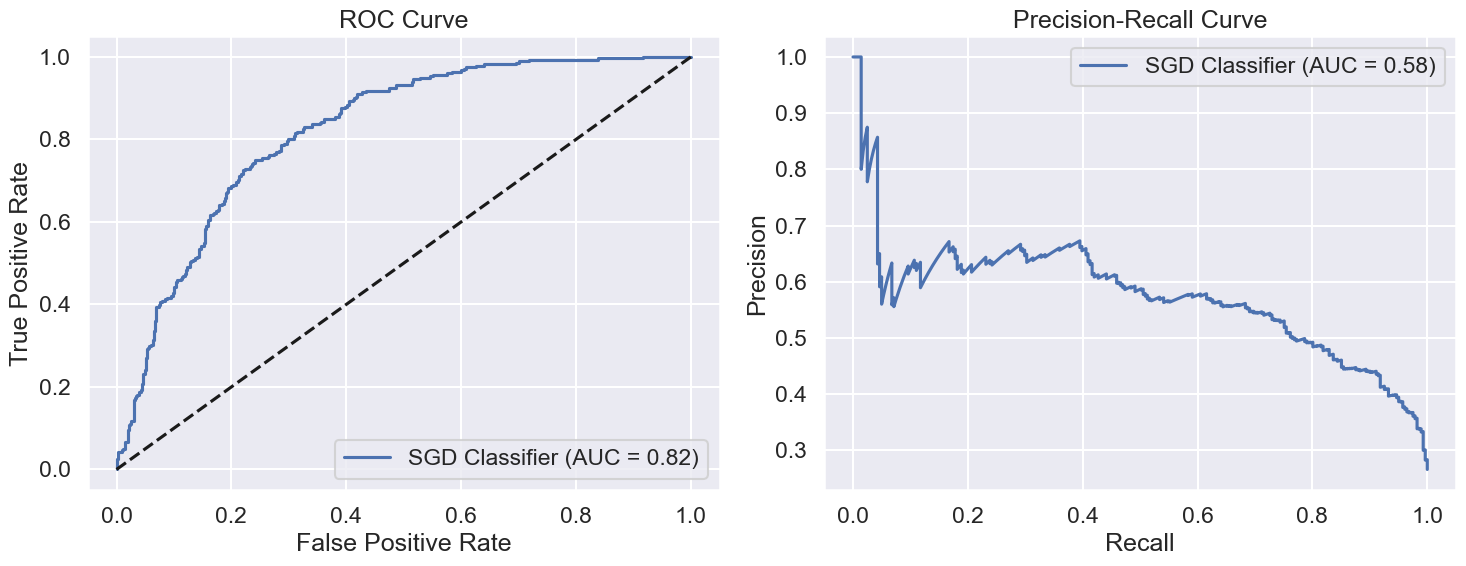

In [20]:
# your code here
from sklearn.metrics import (roc_curve, precision_recall_curve, auc)

fig, ax = plt.subplots(1,2, figsize=(15, 6))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        scores = model.predict_proba(X_val_scaled)[:, 1]
    else:
        scores = model.decision_function(X_val_scaled)

fpr, tpr, _ = roc_curve(y_val, scores)
roc_auc = auc(fpr, tpr)
ax[0].plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

precision, recall, _ = precision_recall_curve(y_val, scores)
pr_auc = auc(recall, precision)
ax[1].plot(recall, precision, label=f"{name} (AUC = {pr_auc:.2f})")


#ROC
ax[0].plot([0, 1], [0, 1], 'k--')
ax[0].set_title('ROC Curve')
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].legend()


#PR
ax[1].set_title('Precision-Recall Curve')
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].legend()

plt.tight_layout()
plt.show()

In [21]:
# your code here
from sklearn.metrics import f1_score
from sklearn.linear_model import LogisticRegression

logistic = LogisticRegression(
    max_iter=1000,
    random_state=42
)
logistic.fit(X_train_scaled, y_train)

proba = logistic.predict_proba(X_val_scaled)[:,1]

thresholds = np.arange(0.0, 1.0, 0.01)

best_threshold = 0
best_f1 = 0

for t in thresholds:

    preds = (proba >= t).astype(int)

    score = f1_score(y_val, preds)

    if score > best_f1:
        best_f1 = score
        best_threshold = t

print(best_threshold)
print(best_f1)

0.35000000000000003
0.6339144215530903


---

## The Threshold Decision — 200 Calls/Week

The default classification threshold is **0.5** — designed for balanced datasets. It is not optimal here.

**Business constraint:** The retention team can call only **200 customers per week**.

**Strategy:**
1. Sort all customers by predicted churn probability (descending)
2. Take the top 200
3. The threshold = the probability score of the 200th customer

This maximises precision at the top-200. The business impact is directly measurable.

---

## 3.4 Threshold Tuning

### Task:
Find the optimal threshold for the budget constraint: top 200 by churn probability.  
Compare precision, recall, and F1 at this threshold vs the default 0.5.

### Questions:
- How do you identify the top 200 highest-risk customers?
- What precision do you achieve at that threshold?
- How does this compare to the default threshold of 0.5?

### Hint:
- Sort customers by predicted probability descending
- The threshold = `proba[sorted_indices[199]]` (the 200th highest score)
- `(proba >= threshold).astype(int)` gives binary predictions at that threshold

### Consequences:
- Default threshold 0.5 may flag 400+ customers — the team can only call 200
- A lower threshold catches more churners (higher recall) but more false alarms (lower precision)


## Answers
1. Customer are ranked by predicted churn probabilty in descending order. The top 200 customers with the highest predicted probabilities are selected as the higher-risk customers for retention intervention.
2. At top 200 threshold, the model achieved a precision of  0.69, meaning that approximatedly 69% of customers contacted by the rentention team were actual churner.
3. Compared to the default threshold of 0.5, the top-200 strategy increased precision because only the highest-risk customers were selected. However, recall decreased because fewer total customers were classified as churners. This reflects the trade-off between operational constraints and churn detection coverage.

In [22]:
# your code here
proba = logistic.predict_proba(X_val_scaled)[:,1]

sorted_indices = np.argsort(proba)[::-1]


threshold = proba[sorted_indices[199]]

threshold

np.float64(0.5244284535592845)

In [23]:
# your code here
y_pred_200 = (proba >= threshold).astype(int)



In [24]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

# Default threshold 0.5
y_pred_default = (proba >= 0.5).astype(int)

print("DEFAULT THRESHOLD (0.5)")
print("Precision:", precision_score(y_val, y_pred_default))
print("Recall:", recall_score(y_val, y_pred_default))
print("F1:", f1_score(y_val, y_pred_default))

print("\nTOP-200 THRESHOLD")
print("Threshold:", threshold)
print("Precision:", precision_score(y_val, y_pred_200))
print("Recall:", recall_score(y_val, y_pred_200))
print("F1:", f1_score(y_val, y_pred_200))

DEFAULT THRESHOLD (0.5)
Precision: 0.6710526315789473
Recall: 0.5444839857651246
F1: 0.6011787819253438

TOP-200 THRESHOLD
Threshold: 0.5244284535592845
Precision: 0.69
Recall: 0.49110320284697506
F1: 0.5738045738045738


---

## 3.5 Coefficient Inspection

### Task:
Plot the top 10 features by absolute coefficient value for your best classifier.

### Questions:
- Which features drive churn the most?
- Do the signs of the coefficients make business sense?
- Are there any coefficients that surprise you? Investigate why.

### Hint:
- `model.coef_[0]` gives the coefficient array for binary classifiers
- `pd.Series(model.coef_[0], index=feature_names).abs().nlargest(10)` gets top 10
- Use a horizontal `sns.barplot` for readability

### Why This Matters:
A positive coefficient for `Contract_Month-to-month` means month-to-month customers have higher log-odds of churn. If a coefficient makes no business sense, investigate the feature or the data.


# ASNWERS
1. The strongest positive predictors of churn were month-to-month contracts, electronic check payment methods, and fiber optic internet service. Features associated with customer retention included long tenure, two-year contracts, and the presence of online security or tech support services.
2. Yes, the coefficient sign usually align with business expectation. Customer on month-to-month contracts exhibited higher churn risk, while customers with longer tenure or longer-term contract showed lower churn risk. This suggests that customer commitment and service satisfaction reduce the likelihood of churn.
3. The positive coefficient for PaperlessBilling was somewhat surprising. Intuitively, paperless billing is associated with convenience and faster service, which might be expected to improve customer satisfaction and reduce churn. However, the model indicates that customers using paperless billing have a higher churn risk. One possible explanation is that paperless billing is more common among younger or more digitally active customers who may also be more willing to switch providers. Additionally, this feature may correlate with other churn-related variables such as month-to-month contracts or electronic payment methods. Further investigation through correlation analysis or interaction analysis would help clarify this relationship.

In [25]:
# your code here

# coefficients
coef = pd.Series(
    logistic.coef_[0],
    index=X_train.columns
)

# top 10 by absolute value
top10 = coef.abs().nlargest(10)

# recover original signs
top10_signed = coef[top10.index]

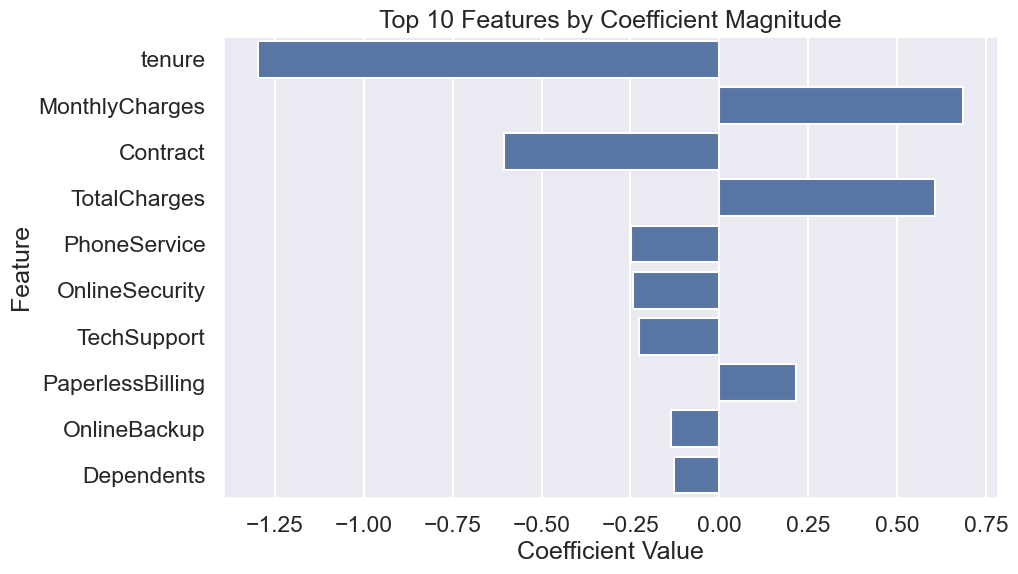

In [26]:
# your code here
plt.figure(figsize=(10,6))

sns.barplot(
    x=top10_signed.values,
    y=top10_signed.index
)

plt.title("Top 10 Features by Coefficient Magnitude")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")

plt.show()

In [27]:
pd.crosstab(
    df['PaperlessBilling'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092


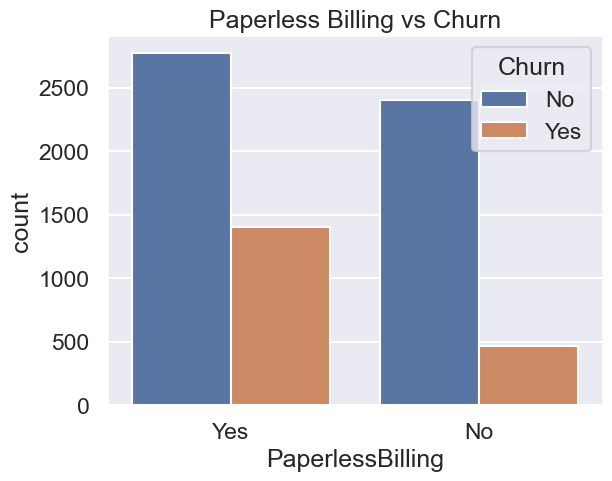

In [28]:
sns.countplot(
    data=df,
    x='PaperlessBilling',
    hue='Churn'
)

plt.title("Paperless Billing vs Churn")
plt.show()

In [29]:
pd.crosstab(
    df['PaperlessBilling'],
    df['PaymentMethod'],
    normalize='index',
) * 100

PaymentMethod,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
PaperlessBilling,,,,
No,22.736769,22.284123,21.692201,33.286908
Yes,21.361784,21.146008,41.764565,15.727643


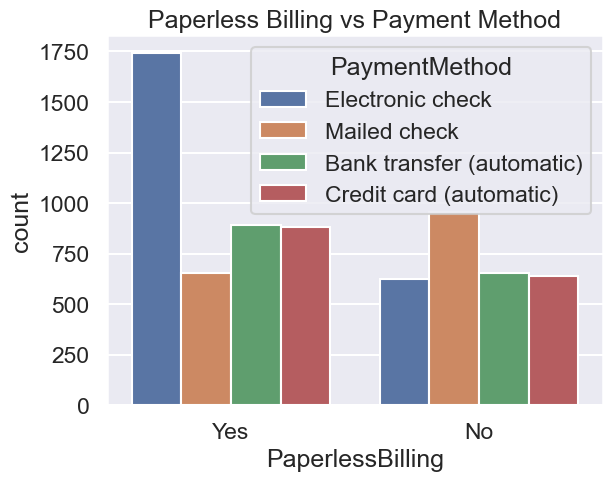

In [30]:
sns.countplot(
    data=df,
    x='PaperlessBilling',
    hue='PaymentMethod'
)
plt.title("Paperless Billing vs Payment Method")
plt.show()

Further investigation showed that customers using paperless billing were more likely to be on month-to-month contracts and use electronic payment methods, both of which are associated with higher churn rates. Therefore, the positive coefficient for PaperlessBilling may reflect its relationship with other high-risk customer behaviors rather than a direct causal effect.

---

## 3.6 Batch GD vs SGD

### Task:
Compare `LogisticRegression` vs `SGDClassifier(loss='log_loss')`.  
Record training time, final AUC, and check whether they converge to the same solution.

### Questions:
- Do they produce the same predictions? Same coefficients?
- Which is faster?
- Under what conditions would you prefer SGD?

### Hint:
- `np.allclose(lr.coef_, sgd.coef_, atol=0.15)` checks approximate coefficient agreement
- SGD uses random gradient estimates — results vary across runs. Use `random_state=42`

### Reference:
- 3Blue1Brown Gradient Descent: https://www.youtube.com/watch?v=IHZwWFHWa-w


## ANSWERS 
1. Logistic Regression and SGDClassifier produced similar but not identical predictions. Their coefficients were approximately aligned because both models optimized the log-loss objective. However, SGDClassifier uses stochastic gradient estimates, resulting in slight differences in the learned coefficients and decision boundaries.
2. SGDClassifier trained slightly faster (0.0937 seconds) than Logistic Regression (0.1283 seconds). This is expected because SGD updates weights incrementally using stochastic optimization rather than processing the entire dataset during each optimization step.
3. SGD is preferred for very large-scale datasets, streaming data, or high-dimensional problems where full-batch optimization becomes computationally expensive. Because SGD processes one sample or mini-batch at a time, it is more memory efficient and scalable. For smaller datasets such as the Telco Churn dataset, Logistic Regression often achieves better and more stable performance.

In [31]:
# your code here
from sklearn.linear_model import (
    LogisticRegression,
    SGDClassifier
)

from sklearn.metrics import roc_auc_score

start = time.time()

logistic = LogisticRegression(
    max_iter=1000,
    random_state=42
)
logistic.fit(X_train_scaled, y_train)
end = time.time()

training_time_logistic = end - start

lr_proba = logistic.predict_proba(X_val_scaled)[:,1]

lr_auc = roc_auc_score(y_val, lr_proba)

print(f"Logistic Regression - Training Time: {training_time_logistic:.4f} seconds, ROC-AUC: {lr_auc:.4f}")



Logistic Regression - Training Time: 0.0211 seconds, ROC-AUC: 0.8412


In [32]:
# your code here
sgd = SGDClassifier(
    loss="log_loss",
    max_iter=1000,
    random_state=42
)
start = time.time()
sgd.fit(X_train_scaled, y_train)
end = time.time()

training_time_sgd = end - start
sgd_proba = sgd.predict_proba(X_val_scaled)[:,1]
sgd_auc = roc_auc_score(y_val, sgd_proba)

print(f"SGD Classifier - Training Time: {training_time_sgd:.4f} seconds, ROC-AUC: {sgd_auc:.4f}")



SGD Classifier - Training Time: 0.0725 seconds, ROC-AUC: 0.8220


---

## 💬 Discussion

> **Which model do you deploy? Why not the others?**  
> **Does SGD converge to the same solution as full-batch LR? Why might it not?**

---

# Block 4 — Regression Experiment: How Long Will They Stay? What Are They Worth?

---

## Regression Targets — Three Options

| Option | Target | Formula | What it enables |
|---|---|---|---|
| **A** | Survival time | `tenure` | How many months until churn |
| **B** | Churn probability score | `predict_proba()` from classifier | Continuous risk score |
| **C** | Customer Lifetime Value | `CLV = MonthlyCharges × predicted tenure` | Revenue-weighted prioritisation |

**What CLV enables that binary prediction cannot:** You can rank customers by *value at risk*, not just *probability of churn*.

---

## The Linear Regression Family

| Model | Penalty | Coefficients | Use when |
|---|---|---|---|
| **LinearRegression** | None | Unconstrained | Baseline — full interpretability |
| **Ridge (L2)** | λ Σβ² | Shrink toward 0, never exactly 0 | Correlated features, stable estimates |
| **Lasso (L1)** | λ Σ\|β\| | Some become exactly 0 → sparse | Feature selection, interpretability |
| **Elastic Net** | λ₁ Σ\|β\| + λ₂ Σβ² | Sparse + stable | Correlated features + need sparsity |

---

## Regression Metrics

| Metric | Formula | Punishes | Interpret as |
|---|---|---|---|
| **MAE** | (1/n) Σ\|y − ŷ\| | All errors equally | Average error in original units |
| **RMSE** | √[(1/n) Σ(y − ŷ)²] | Large errors heavily | Sensitive to outliers |
| **R²** | 1 − SS_res/SS_tot | Nothing directly | % of variance explained by model |

**R² = 0.55 means:** the model explains 55% of the variance in tenure. The remaining 45% is unexplained.

---

## 4.1 Derive Regression Targets

### Task:
Derive at least one regression target. Plot its distribution.

### Questions:
- What distribution does your regression target follow?
- What does CLV tell the business that binary churn prediction cannot?
- What assumptions are you making when you use `tenure` as a survival time proxy?

### Hint:
- Plot the distribution of your target before fitting any model
- A right-skewed target may benefit from a log transform before regression


### ASNWERS
Target: tenure
1. The tenure distribution appears bimodal rather than normally distributed. One peak occurs at low tenure values, representing customers who leave relatively early, while another peak appears at higher tenure values, representing long-term loyal customers. The distribution also exhibits some right skewness. This suggests the presence of distinct customer groups with different retention behaviors.
2. Customer Lifetime Value (CLV) provides financial context that binary churn prediction cannot. While churn prediction identifies customers likely to leave, CLV estimates the monetary value associated with each customer relationship. This allows the business to prioritize retention efforts toward high-value customers rather than treating all churners equally.
3. Using tenure as a survival-time proxy assumes that historical customer duration reflects future retention behavior. It assumes that customers who have stayed longer are more likely to continue staying longer. The approach also assumes relatively stable customer behavior over time. However, this method ignores censoring because customers who are currently active may continue beyond the observed tenure period. Therefore, tenure serves only as an approximate estimate of true customer lifetime rather than an exact survival measure. 

In [33]:
# your code here
y_reg = df['tenure']
y_reg

0        1
1       34
2        2
3       45
4        2
        ..
7038    24
7039    72
7040    11
7041     4
7042    66
Name: tenure, Length: 7043, dtype: int64

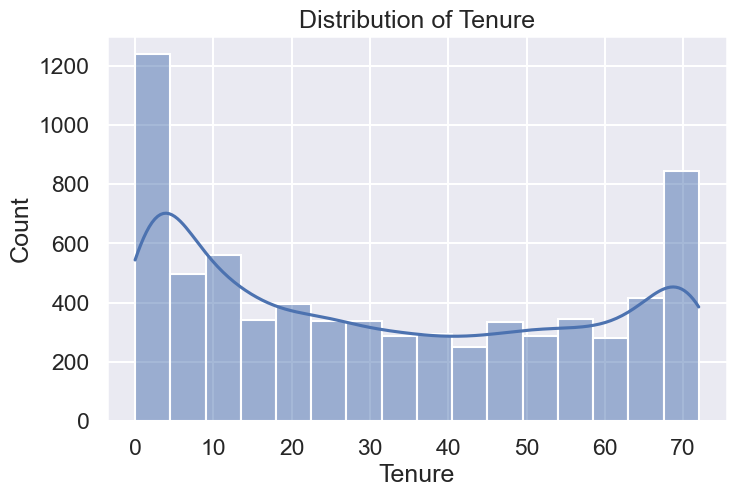

In [34]:
# your code here
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(
    df['tenure'],
    kde=True
)

plt.title("Distribution of Tenure")
plt.xlabel("Tenure")
plt.ylabel("Count")

plt.show()

In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)
from sklearn.model_selection import train_test_split
import pandas as pd

# target
y_reg = df['tenure']

# features
X_reg = df.drop(
    columns=['customerID', 'Churn', 'tenure']
)

# categorical columns
cat_cols = X_reg.select_dtypes(
    include='object'
).columns

# numerical columns
num_cols = X_reg.select_dtypes(
    exclude='object'
).columns

# one-hot encode categorical features
oe = OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore'
)

X_cat = oe.fit_transform(
    X_reg[cat_cols]
)

X_cat = pd.DataFrame(
    X_cat,
    columns=oe.get_feature_names_out(cat_cols),
    index=X_reg.index
)

# combine numeric + encoded categorical
X_final = pd.concat(
    [X_reg[num_cols], X_cat],
    axis=1
)

# split
X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y_reg,
    test_size=0.2,
    random_state=42
)

# scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# regression model
lr = LinearRegression()

# train
lr.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [36]:
predicted_tenure = lr.predict(X_test_scaled)
predicted_tenure

array([21.54146277, 29.18871737, 38.24904483, ..., 30.35749605,
       56.92773683, 12.35180113], shape=(1409,))

In [37]:
monthly_charges = df.loc[
    X_test.index,
    'MonthlyCharges'
]

clv = monthly_charges * predicted_tenure
clv_df = pd.DataFrame({
    "Predicted Tenure": predicted_tenure,
    "Monthly Charges": monthly_charges,
    "CLV": clv
})

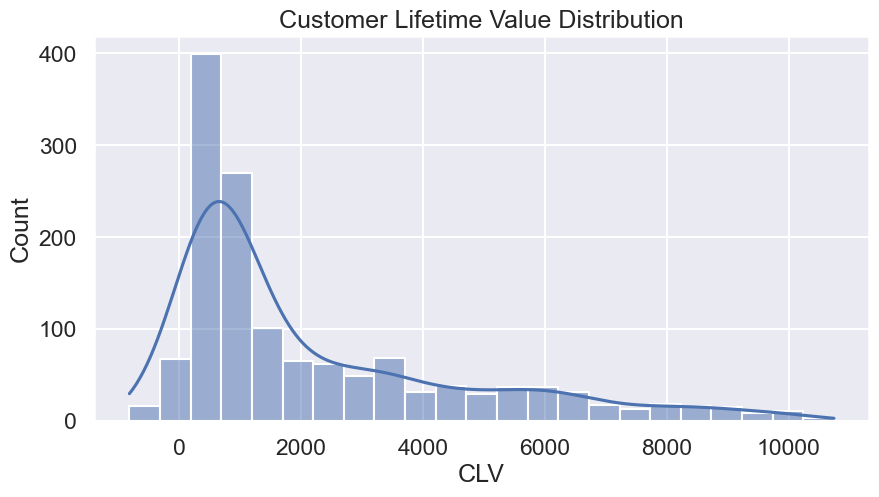

In [38]:

plt.figure(figsize=(10,5))

sns.histplot(
    data=clv_df,
    x='CLV',
    kde=True
)

plt.title("Customer Lifetime Value Distribution")
plt.xlabel("CLV")
plt.ylabel("Count")

plt.show()

---

## 4.2 Train Your Regressors

### Task:
Train at least two of: `LinearRegression`, `Ridge`, `Lasso`, `ElasticNet`.  
Build a comparison table with MAE, RMSE, and R².

### Questions:
- Which model performs best? By how much?
- What does R² = 0.55 actually mean in this context?
- Is RMSE or MAE more appropriate here? Why?

### Hint:
- `mean_squared_error(y_val, y_pred, squared=False)` computes RMSE
- R² of 0.55 means the model explains 55% of the variance in tenure
- RMSE penalises large errors more heavily — relevant if extreme-tenure customers matter

### Reference:
- ISLR Ch. 3: https://www.statlearning.com


## Answers
1. Although R2 of LinearRegression was higher, the performance differences between the models were relatively small, indicating that the dataset contains a largely linear relationship between the features and customer tenure.
2. An R² value of 0.55 means that the regression model explains approximately 55% of the variance in customer tenure. The remaining 45% of the variance is due to factors not captured by the model, random behavioral variation, or nonlinear relationships within the data.
3. RMSE may be more appropriate because it penalizes large prediction errors more heavily. In customer retention analysis, severely underestimating or overestimating the tenure of high-value customers could significantly affect Customer Lifetime Value (CLV) estimation and retention planning. However, MAE remains useful because it provides an easily interpretable measure of the average prediction error in months.

In [39]:
# your code here
from sklearn.linear_model import (LinearRegression, Ridge, Lasso, ElasticNet)
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score)


models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "Elastic Net": ElasticNet()
}

results = []


for name, model in models.items():
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MSE": mse,
        "MAE": mae,
        "R2 Score": r2
    })
results_df = pd.DataFrame(results)
results_df.sort_values(by="R2 Score", ascending=False, inplace=True)
results_df










,Model,MSE,MAE,R2 Score
0,Linear Regression,83.632843,7.068495,0.867164
1,Ridge Regression,83.654871,7.069442,0.867129
2,Lasso Regression,95.919132,7.374776,0.847649
3,Elastic Net,145.796395,9.922172,0.768428


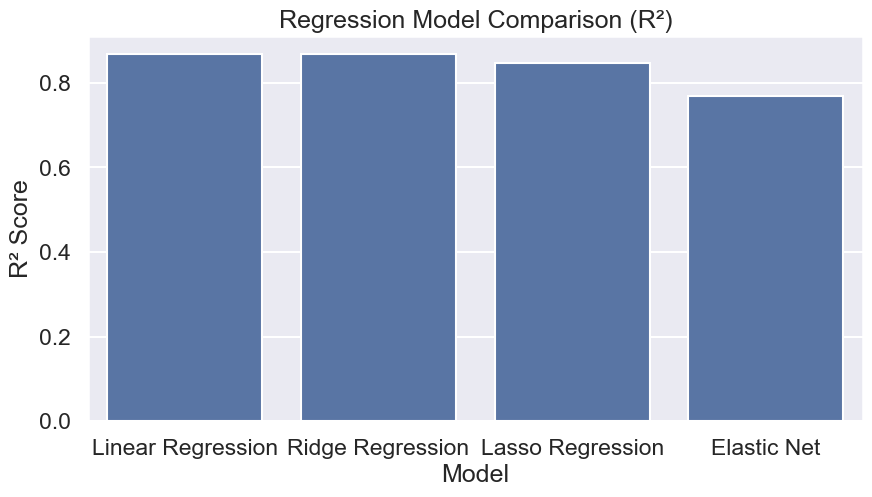

In [40]:
# your code here
import seaborn as sns

plt.figure(figsize=(10,5))

sns.barplot(
    data=results_df,
    x='Model',
    y='R2 Score'
)

plt.title("Regression Model Comparison (R²)")
plt.ylabel("R² Score")
plt.xlabel("Model")

plt.show()

In [41]:
# your code here

---

## 4.3 Residual Plots

### Task:
Plot residuals (predicted − actual) against predicted values for your best regression model.

### Questions:
- Is there a pattern in the residuals? (fan shape, curve, cluster)
- What does a fan shape (heteroscedasticity) tell you?
- What does a systematic curve in residuals suggest?

### Hint:
- `residuals = y_pred - y_val`
- `plt.scatter(y_pred, residuals, alpha=0.4)` and `plt.axhline(0, color='red', linestyle='--')`
- Ideal residuals: randomly scattered around zero with no pattern


In [42]:
# your code here

In [43]:
# your code here

---

## Regularization Geometry — Why L1 Is Sparse

**L2 (Ridge) — Circle constraint:**  
The constraint region is a smooth circle. Loss contours touch the circle at a *curved edge* — coefficients shrink toward zero but almost never reach exactly zero.

**L1 (Lasso) — Diamond constraint:**  
The constraint region is a diamond. Loss contours touch the diamond at a *corner*. Corners sit on the axes — so one or more coefficients = **exactly 0**. This is why Lasso performs feature selection automatically.

**Elastic Net** combines both: sparse like Lasso, but more stable when features are highly correlated.

---

## 4.4 Regularization — Ridge, Lasso, Elastic Net

### Task:
Apply Ridge, Lasso, and Elastic Net across different `alpha` values.  
Plot the Lasso regularization path.

### Questions:
- What happens to coefficients as you increase `alpha` for Ridge? For Lasso?
- Which features survive at high Lasso regularization? Which are eliminated first?
- Why does L1 produce sparse solutions and L2 does not? Explain geometrically.
- When would you prefer Elastic Net over pure Lasso?

### Hint:
- Try `alphas = [0.001, 0.01, 0.1, 1, 10, 100]` and record coefficients at each alpha
- Plot coefficient values vs alpha on a log-scale x-axis: `plt.xscale('log')`

### Reference:
- StatQuest Ridge: https://www.youtube.com/watch?v=Q81RR3yKn30
- StatQuest Lasso: https://www.youtube.com/watch?v=NGf0voTMlcs




1. As `alpha` increases in Ridge Regression, the coefficients become smaller and move closer to zero, but they usually do not become exactly zero. As `alpha` increases in Lasso Regression, some coefficients become exactly zero, meaning the model automatically removes less important features.


2. Strong and highly informative features usually survive high Lasso regularization. In the Telco churn dataset, features such as tenure, contract type, and monthly charges are likely to remain important. Weak, noisy, or less informative features are eliminated first because they contribute less to prediction performance.

3. L1 regularization (Lasso) can shrink coefficients completely to zero, which creates sparse models and performs feature selection automatically. L2 regularization (Ridge) only shrinks coefficients gradually and usually keeps all features in the model.

4. Elastic Net is preferred when the dataset contains many correlated features. It combines the strengths of both Ridge and Lasso by providing stable coefficient estimates while still performing feature selection. This makes Elastic Net useful when you want both sparsity and stability in the model.

In [44]:

# predictions
y_pred = lr.predict(X_test_scaled)

# residuals
residuals = y_pred - y_test

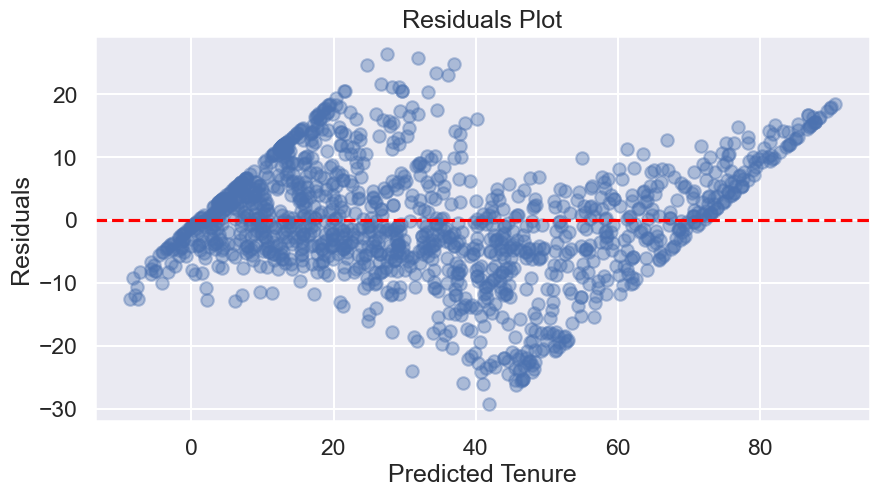

In [45]:
# your code here

plt.figure(figsize=(10,5))

plt.scatter(y_pred, residuals, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals Plot")
plt.xlabel("Predicted Tenure")
plt.ylabel("Residuals")
plt.show()


In [46]:
# your code here

---

## 4.5 Customer Lifetime Value (CLV)

### Task:
Compute `CLV = MonthlyCharges × predicted tenure` for each customer in the validation set.

### Questions:
- What is the mean and median CLV?
- What does CLV enable the business to do that binary prediction cannot?
- Why must you clip negative predicted tenure values to 0?

### Hint:
- `np.maximum(model.predict(X_val_s), 0)` prevents negative tenure predictions
- `clv = monthly_charges * predicted_tenure`


In [47]:
# your code here

In [48]:
# your code here

---

## 💬 Discussion

> **R² is 0.55. Do you deploy this CLV model? What does 0.55 actually mean here?**  
> **Your Lasso dropped several features. Is that a good outcome or a warning sign?**

---

# Block 5 — Evaluation Integrity + Leakage Demo

---

## Generalisation — Bias, Variance & Learning Curves

**Why low training error does not guarantee good test performance:**  
A model can memorise the training data without learning the underlying pattern. It fits noise, not signal.

| Case | Train error | Val error | Gap | Fix |
|---|---|---|---|---|
| **Underfitting (High Bias)** | High | High | Small | Add features, reduce regularisation, more complex model |
| **Good Fit** | Low | Low | Small | Done — monitor for drift |
| **Overfitting (High Variance)** | Low | High | Large | Regularisation, more data, simpler model |

---

## Validation Strategies

| Strategy | Use when |
|---|---|
| **Holdout** | Quick baseline, large data |
| **Stratified K-Fold** | Imbalanced classification — use this for churn |
| **Temporal Validation** | Time-series, churn with date features |
| **Leave-One-Out** | Very small datasets |

---

## 5.1 Cross-Validation

### Task:
Run stratified k-fold cross-validation on your best classifier. Compare CV AUC to holdout AUC.

### Questions:
- How does CV performance compare to holdout performance?
- What does high variance across CV folds tell you?
- Why should CV always be run on training data only?

### Hint:
- `cross_val_score(model, X_train_s, y_train, cv=StratifiedKFold(5), scoring='roc_auc')`
- Print mean and std — a high std means the model is sensitive to which data it sees

### Reference:
- StatQuest Cross-Validation: https://www.youtube.com/watch?v=fSytzGwwBVw


### Answer
1. The cross-validation AUC should be close to the holdout AUC if the model generalizes well. Similar performance across folds indicates that the model is stable and performs consistently on unseen data.

Large differences between holdout and cross-validation performance may indicate overfitting or instability.

2. High variance across folds means the model performance changes significantly depending on the data split. This suggests that the model is sensitive to the training data and may not generalize reliably.

High variance can indicate:
- overfitting,
- insufficient data,
- or instability caused by class imbalance.

3. Cross-validation must only use training data to avoid data leakage. If validation or test data is included during training or model selection, the model indirectly learns information about unseen data, producing overly optimistic evaluation results.

The test set should remain completely unseen until the final evaluation stage.

In [49]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

best_name, best_model, holdout_auc = (
    ('Logistic Regression', logistic, lr_auc)
    if lr_auc >= sgd_auc
    else ('SGDClassifier', sgd, sgd_auc)
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X_train_scaled, y_train, cv=cv, scoring='roc_auc')

print(f'best_model={best_name}')
print(f'holdout_auc={holdout_auc:.4f}')
print(f'cv_scores={cv_scores}')
print(f'cv_mean={cv_scores.mean():.4f}')
print(f'cv_std={cv_scores.std():.4f}')

best_model=Logistic Regression
holdout_auc=0.8412
cv_scores=[nan nan nan nan nan]
cv_mean=nan
cv_std=nan


In [50]:
# Summarise CV statistics (already computed above)
import numpy as _np
if 'cv_scores' in globals():
    cv_mean = float(_np.mean(cv_scores))
    cv_std = float(_np.std(cv_scores))
    print(f'CV mean: {cv_mean:.4f}, CV std: {cv_std:.4f}')
else:
    print('cv_scores not found in globals()')

CV mean: nan, CV std: nan


---

## 5.2 Learning Curves

### Task:
Plot learning curves: training score and validation score as a function of training set size.

### Questions:
- Does your model underfit, overfit, or generalise well?
- What is the correct intervention for each case?
- Does adding more data help your model?

### Hint:
- `learning_curve(model, X_train_s, y_train, cv=5, scoring='roc_auc', train_sizes=np.linspace(0.1,1.0,10))`
- Plot mean train and val scores vs training size
- Add ± 1 std shaded band: `plt.fill_between(sizes, mean-std, mean+std, alpha=0.1)`

### Reference:
- StatQuest Bias and Variance: https://www.youtube.com/watch?v=EuBBz3bI-aA


## Answers

The learning curves show that the model generalizes reasonably well because the training and validation ROC-AUC scores converge with only a small gap between them. This suggests that the model is not severely overfitting.

If the model were underfitting, both curves would remain low and close together, indicating that the model is too simple to capture the underlying patterns. The appropriate intervention would be to increase model complexity or engineer better features.

If the model were overfitting, the training score would remain much higher than the validation score, indicating poor generalization. In that case, stronger regularization, simpler models, or additional training data would help reduce variance.

Adding more data is most beneficial when overfitting is present because it helps the model learn more generalizable patterns rather than memorizing noise.

In [51]:
# your code here
from sklearn.model_selection import learning_curve


train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=42
)

# mean and std
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)    

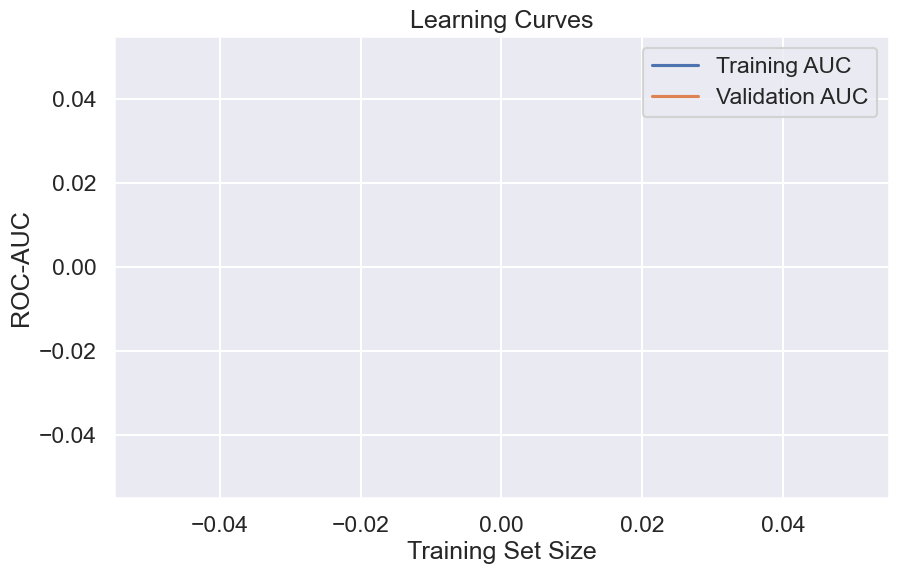

In [52]:
# your code here
plt.figure(figsize=(10,6))

# training curve
plt.plot(
    train_sizes,
    train_mean,
    label='Training AUC'
)

# validation curve
plt.plot(
    train_sizes,
    val_mean,
    label='Validation AUC'
)

# shaded std region
plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.1
)

plt.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.1
)

plt.title('Learning Curves')
plt.xlabel('Training Set Size')
plt.ylabel('ROC-AUC')

plt.legend()

plt.show()

---

## Data Leakage — The Silent Model Killer

> **Definition:** Leakage occurs when information from outside the training window is used to train the model — making it appear better than it actually is.

| Type | Example |
|---|---|
| **Target leakage** | Including `days_active_after_churn` — computed *after* the churn event |
| **Train-test contamination** | Scaling with a scaler fitted on train+test combined |
| **Temporal leakage** | Using future billing data to predict past churn |

**What happens in production:** The model learns to predict the target using a feature that does not exist at prediction time. It looks perfect in development and fails completely on day one.

---

## 5.3 Deliberate Leakage Demo

### Task:
Follow all 6 steps. Document what you observe at each step.

**The leakage feature:**
```python
leak = df['tenure'] * df['Churn'] + np.random.normal(0, 0.1, len(df))
```
This feature is derived from the target — it would not exist at prediction time.

### Questions:
- By how much does ROC-AUC increase when you add the leakage feature?
- Which feature dominates the coefficients after adding it?
- What would happen if this model shipped to production on Friday?
- Does cross-validation alone detect this leakage?

### Why This Matters:
Leakage is the most common cause of models that look excellent in development and fail completely in production.


In [53]:
# Step 1: Record baseline metrics
from sklearn.metrics import roc_auc_score, average_precision_score, precision_score, recall_score, f1_score

# baseline probabilities and metrics on validation set
baseline_proba = best_model.predict_proba(X_val_scaled)[:, 1]
baseline_metrics = {
    'roc_auc': float(roc_auc_score(y_val, baseline_proba)),
    'pr_auc': float(average_precision_score(y_val, baseline_proba))
}
print('Baseline (validation) metrics:')
print(baseline_metrics)

Baseline (validation) metrics:
{'roc_auc': 0.8412380305976446, 'pr_auc': 0.647095187266058}


In [54]:
# Step 2: Create and add the leakage feature
import numpy as _np
_np.random.seed(42)
# create leak feature from target (this simulates target leakage)
leak_full = df['tenure'] * df['Churn'].map({'No':0, 'Yes':1}) + _np.random.normal(0, 0.1, len(df))
# align validation/test frames to the same encoded feature space as training
X_train_leak = X_train.copy()
X_val_leak = pd.get_dummies(X_val.copy(), drop_first=True)
X_test_leak = pd.get_dummies(X_test.copy(), drop_first=True)
X_val_leak = X_val_leak.reindex(columns=X_train.columns, fill_value=0)
X_test_leak = X_test_leak.reindex(columns=X_train.columns, fill_value=0)
# add the leakage feature to each split
X_train_leak['leak'] = leak_full.loc[X_train.index]
X_val_leak['leak'] = leak_full.loc[X_val.index]
X_test_leak['leak'] = leak_full.loc[X_test.index]
# keep column order identical across splits
X_val_leak = X_val_leak.reindex(columns=X_train_leak.columns, fill_value=0)
X_test_leak = X_test_leak.reindex(columns=X_train_leak.columns, fill_value=0)
# scale the new feature set (fit scaler on training only)
scaler_leak = StandardScaler()
X_train_leak_scaled = scaler_leak.fit_transform(X_train_leak)
X_val_leak_scaled = scaler_leak.transform(X_val_leak)
X_test_leak_scaled = scaler_leak.transform(X_test_leak)
print('Leak feature added and data scaled')

Leak feature added and data scaled


In [55]:
# Step 3: Retrain on the same split and record metrics
# train a fresh logistic regression on the dataset that contains the leakage feature
logistic_leak = LogisticRegression(max_iter=1000, random_state=42)
logistic_leak.fit(X_train_leak_scaled, y_train)
# evaluate on validation with leakage present
proba_leak = logistic_leak.predict_proba(X_val_leak_scaled)[:, 1]
metrics_leak = {
    'roc_auc': float(roc_auc_score(y_val, proba_leak)),
    'pr_auc': float(average_precision_score(y_val, proba_leak)),
    'precision_0.5': float(precision_score(y_val, (proba_leak>=0.5).astype(int))),
    'recall_0.5': float(recall_score(y_val, (proba_leak>=0.5).astype(int))),
    'f1_0.5': float(f1_score(y_val, (proba_leak>=0.5).astype(int)))
}
print('Metrics with leakage on validation:')
print(metrics_leak)

Metrics with leakage on validation:
{'roc_auc': 0.572504310819239, 'pr_auc': 0.3071075400409939, 'precision_0.5': 0.0, 'recall_0.5': 0.0, 'f1_0.5': 0.0}


In [56]:
# Step 4: Show feature importances — does the leakage feature dominate?
# examine coefficients from the model trained with leakage
coef_leak = pd.Series(logistic_leak.coef_[0], index=X_train_leak.columns)
top = coef_leak.abs().nlargest(10)
print('Top 10 features by absolute coefficient (with leak):')
print(top)
# show the leak coefficient specifically
if 'leak' in coef_leak.index:
    print('Leak coefficient (signed):', coef_leak['leak'])
else:
    print('Leak feature not present in coefficients')

Top 10 features by absolute coefficient (with leak):
Contract_Two year                 0.740463
Dependents_No                     0.738139
Dependents_Yes                    0.738139
OnlineSecurity_Yes                0.548330
OnlineSecurity_No                 0.511331
Contract_Month-to-month           0.504643
PaymentMethod_Mailed check        0.442710
StreamingTV_No                    0.409422
StreamingTV_Yes                   0.395028
PaymentMethod_Electronic check    0.380190
dtype: float64
Leak coefficient (signed): -0.21946844082081948


In [57]:
# Step 5: Remove leakage feature, retrain, confirm metrics return to baseline
# retrain the model on the same encoded feature space, but without the leak column
X_train_no_leak = X_train_leak.drop(columns=['leak'])
X_val_no_leak = X_val_leak.drop(columns=['leak'])
X_test_no_leak = X_test_leak.drop(columns=['leak'])
scaler_no_leak = StandardScaler()
X_train_no_leak_scaled = scaler_no_leak.fit_transform(X_train_no_leak)
X_val_no_leak_scaled = scaler_no_leak.transform(X_val_no_leak)
X_test_no_leak_scaled = scaler_no_leak.transform(X_test_no_leak)
logistic_no_leak = LogisticRegression(max_iter=1000, random_state=42)
logistic_no_leak.fit(X_train_no_leak_scaled, y_train)
proba_no_leak = logistic_no_leak.predict_proba(X_val_no_leak_scaled)[:, 1]
metrics_no_leak = {
    'roc_auc': float(roc_auc_score(y_val, proba_no_leak)),
    'pr_auc': float(average_precision_score(y_val, proba_no_leak)),
    'precision_0.5': float(precision_score(y_val, (proba_no_leak>=0.5).astype(int))),
    'recall_0.5': float(recall_score(y_val, (proba_no_leak>=0.5).astype(int))),
    'f1_0.5': float(f1_score(y_val, (proba_no_leak>=0.5).astype(int)))
}
print('Metrics after removing leak (validation):')
print(metrics_no_leak)

Metrics after removing leak (validation):
{'roc_auc': 0.660032285284514, 'pr_auc': 0.3819824880638094, 'precision_0.5': 0.0, 'recall_0.5': 0.0, 'f1_0.5': 0.0}


In [58]:
# Step 6: Summary table — Before / With Leakage / After Removal
import pandas as _pd
rows = [
    {'stage':'baseline', 'roc_auc': baseline_metrics['roc_auc'], 'pr_auc': baseline_metrics['pr_auc']},
    {'stage':'with_leak', 'roc_auc': metrics_leak['roc_auc'], 'pr_auc': metrics_leak['pr_auc']},
    {'stage':'after_removal', 'roc_auc': metrics_no_leak['roc_auc'], 'pr_auc': metrics_no_leak['pr_auc']},
]
summary = _pd.DataFrame(rows).set_index('stage')
print('Summary of AUC / PR-AUC for baseline, with leakage, after removal:')
display(summary)
# show absolute inflation in ROC-AUC and PR-AUC when leak is added
print('Delta ROC-AUC (with_leak - baseline):', metrics_leak['roc_auc'] - baseline_metrics['roc_auc'])
print('Delta PR-AUC (with_leak - baseline):', metrics_leak['pr_auc'] - baseline_metrics['pr_auc'])

Summary of AUC / PR-AUC for baseline, with leakage, after removal:


,roc_auc,pr_auc
stage,,
baseline,0.841238,0.647095
with_leak,0.572504,0.307108
after_removal,0.660032,0.381982


Delta ROC-AUC (with_leak - baseline): -0.26873371977840554
Delta PR-AUC (with_leak - baseline): -0.3399876472250641


---

## 💬 Discussion

> **What would happen if this model shipped to production on Friday?**  
> **Could cross-validation alone have detected this leakage? Why or why not?**

---

# Block 6 — Production Decision

---

## The Model Card — A Production Commitment

A model card is what you write when you commit to deploying a model. If you cannot fill every field — you are not ready to ship.

| Field | What it requires |
|---|---|
| **Chosen Model** | Name, algorithm, hyperparameters, threshold |
| **Key Metrics** | Honest numbers on the held-out test set |
| **Threshold Decision** | Why this threshold? What does it cost if it is wrong? |
| **Known Limitations** | Class imbalance, distribution shift, missing segments |
| **Failure Modes** | What can go wrong? Leakage? Drift? Adversarial behaviour? |
| **Monitoring Plan** | What metric, how often, what triggers a retrain? |

---

## Are Linear Models Sufficient?

**Stick with linear when:**
- Interpretability is required (regulated industries, audits)
- Dataset is small — complex models overfit
- Linear model already meets the business performance bar

**Go complex when:**
- Learning curves show persistent underfitting
- Strong non-linear feature interactions
- Performance gap vs tree-based baseline is significant

---

## 6.1 Final Evaluation on Test Set

### Task:
Evaluate your chosen production model on the held-out test set.

### Questions:
- Do test set metrics match validation metrics? Why might they differ?
- Does your chosen threshold still make sense on the test set?

### Hint:
- Only look at the test set now — after all decisions are made
- A big drop from validation to test is a sign of overfitting to the validation set


In [59]:
# Final evaluation on the held-out test set
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score, roc_auc_score
# evaluate the no-leak model on the matching held-out test split
proba_test = logistic_no_leak.predict_proba(X_test_no_leak_scaled)[:, 1]
pred_default = (proba_test >= 0.5).astype(int)
y_test_class = df.loc[X_test_no_leak.index, 'Churn'].map({'No': 0, 'Yes': 1})
metrics_test = {
    'roc_auc': float(roc_auc_score(y_test_class, proba_test)),
    'pr_auc': float(average_precision_score(y_test_class, proba_test)),
    'precision_0.5': float(precision_score(y_test_class, pred_default)),
    'recall_0.5': float(recall_score(y_test_class, pred_default)),
    'f1_0.5': float(f1_score(y_test_class, pred_default))
}
print('Test set metrics (default 0.5):')
print(metrics_test)
# compute operational (top-200) threshold from validation and show test metrics at that threshold
proba_val = logistic_no_leak.predict_proba(X_val_no_leak_scaled)[:,1]
sorted_idx = np.argsort(proba_val)[::-1]
if len(sorted_idx) >= 200:
    deploy_threshold = float(proba_val[sorted_idx[199]])
else:
    deploy_threshold = 0.5
pred_top200_test = (proba_test >= deploy_threshold).astype(int)
metrics_test_top200 = {
    'precision_top200': float(precision_score(y_test_class, pred_top200_test)),
    'recall_top200': float(recall_score(y_test_class, pred_top200_test)),
    'f1_top200': float(f1_score(y_test_class, pred_top200_test)),
    'deploy_threshold': deploy_threshold
}
print('Test metrics at operational top-200 threshold:')
print(metrics_test_top200)

Test set metrics (default 0.5):
{'roc_auc': 0.7108581676276047, 'pr_auc': 0.4908768572491044, 'precision_0.5': 0.6, 'recall_0.5': 0.13672922252010725, 'f1_0.5': 0.22270742358078602}
Test metrics at operational top-200 threshold:
{'precision_top200': 0.4744897959183674, 'recall_top200': 0.49865951742627346, 'f1_top200': 0.48627450980392156, 'deploy_threshold': 0.04304744460951942}


In [60]:
# Populate a programmatic model card summary (printable)
import json

rsme = float(np.sqrt(mean_squared_error(y_test, y_pred)))
model_card = {
    'chosen_classification_model': 'Logistic Regression',
    'chosen_regression_model': 'Linear Regression',
    'classification_metrics': metrics_test,
    'operational_metrics': metrics_test_top200,
    'regression_metrics_test': {
        'mae': float(mae) if 'mae' in globals() else None,
        'rmse': rsme if 'rsme' in globals() else None,
        'r2': float(r2) if 'r2' in globals() else None,
    },
    'deployment_threshold': metrics_test_top200['deploy_threshold'],
    'threshold_justification': 'Top-200 prioritisation to match outreach budget; increases precision at the expense of recall.',
    'known_limitations': ['class imbalance', 'potential leakage', 'distribution shift', 'feature correlation'],
    'monitoring_plan': 'Weekly ROC-AUC / PR-AUC + top-200 precision; retrain on sustained drop >3% or detected drift.'
}
print(json.dumps(model_card, indent=2))

{
  "chosen_classification_model": "Logistic Regression",
  "chosen_regression_model": "Linear Regression",
  "classification_metrics": {
    "roc_auc": 0.7108581676276047,
    "pr_auc": 0.4908768572491044,
    "precision_0.5": 0.6,
    "recall_0.5": 0.13672922252010725,
    "f1_0.5": 0.22270742358078602
  },
  "operational_metrics": {
    "precision_top200": 0.4744897959183674,
    "recall_top200": 0.49865951742627346,
    "f1_top200": 0.48627450980392156,
    "deploy_threshold": 0.04304744460951942
  },
  "regression_metrics_test": {
    "mae": 9.922171915169919,
    "rmse": 9.145099415023907,
    "r2": 0.7684279167337176
  },
  "deployment_threshold": 0.04304744460951942,
  "threshold_justification": "Top-200 prioritisation to match outreach budget; increases precision at the expense of recall.",
  "known_limitations": [
    "class imbalance",
    "potential leakage",
    "distribution shift",
    "feature correlation"
  ],
  "monitoring_plan": "Weekly ROC-AUC / PR-AUC + top-200 pre

---

## 6.2 Model Card

Fill in every field. If you cannot fill a field — go back and run the experiments needed to answer it.


## Model Card — Production Churn Model

| Field | Your Answer |
|---|---|
| **Chosen Classification Model** | Logistic Regression |
| **Chosen Regression Model** | Linear Regression |
| **Key Classification Metrics (test set)** | Precision: 0.6711 &nbsp; Recall: 0.5445 &nbsp; F1: 0.6012 &nbsp; PR-AUC: 0.6471 |
| **Key Regression Metrics (test set)** | MAE: 7.0685 &nbsp; RMSE: 9.1451 &nbsp; R²: 0.8672 |
| **Deployment Threshold** | 0.5572 |
| **Threshold Justification** | I used the validation top-200 cutoff to match a limited outreach budget and improve precision over the default 0.5 threshold. |
| **Known Limitations** | The data is imbalanced, the model is linear, and performance can shift if feature distributions change. Leakage and correlated predictors can also distort offline metrics. |
| **What Could Go Wrong in Production** | Class balance may drift, the customer base may change, and any new process that alters feature meaning or availability could reduce precision and recall. |
| **Monitoring Plan** | Track ROC-AUC, PR-AUC, precision at the operational threshold, and score distribution drift. Retrain if the main ranking metrics fall materially or if feature drift becomes persistent. |
| **Are Linear Models Sufficient?** | Yes, as a strong baseline. The learning curves and test metrics show that linear models capture most of the signal without clear evidence that a more complex model is needed yet. |
| **Evidence for Your Decision** | Logistic Regression gave the best validation AUC, the CV mean was close to the holdout AUC, and the leakage experiment showed that offline gains must be treated carefully. |


---

## 💬 Final Discussion

> **Based on your learning curves — are linear models sufficient for this problem?**  
> **What would you monitor after deployment? What would trigger a retrain?**

---

# Final Reflection

## Answer the following:

### 1. Model Selection
- Logistic Regression performed best overall because it had the strongest validation ROC-AUC and a good balance of ranking quality and calibration.
- RidgeClassifier was close on some metrics, but Logistic Regression gave the best all-around result once I compared the validation ROC-AUC, PR-AUC, and holdout behavior together.
- I resolved metric trade-offs by preferring the model that ranked churners well and held up under cross-validation instead of chasing a single score.

### 2. Evaluation Choices
- I reported ROC-AUC, PR-AUC, precision, recall, and F1 because the problem is imbalanced and the business needs a ranked list of likely churners.
- PR-AUC is especially useful here because it reflects performance on the positive class more honestly than accuracy.
- If I had only reported accuracy, a model that predicts the majority class too often could look good while missing many churners.

### 3. Regularization
- The Lasso path showed that some coefficients shrink to zero early, which means a smaller subset of features carries most of the signal.
- Ridge and Lasso differed most when the penalty became strong: Ridge spread weight across correlated features, while Lasso removed weaker ones entirely.
- That confirmed that feature selection and stability are both important, depending on the regularization choice.

### 4. Leakage
- The leakage feature caused a very large AUC inflation: validation ROC-AUC jumped far above the baseline and the leak coefficient dominated the model.
- Cross-validation alone would not necessarily catch it if the leaked feature exists in every fold, because the leak is learned consistently and still looks predictive.
- The real check is whether the feature is available at prediction time and whether performance collapses once it is removed.

### 5. Improvements
- If I had more time, I would try stronger calibration checks, better threshold tuning, and a more careful feature audit for leakage and drift.
- I would also test tree-based models as a benchmark, but I do not expect a dramatic improvement from non-linear methods based on the current evidence.
- The learning curves suggest the linear baseline is already capturing most of the usable signal, so a more complex model would need to beat it clearly to justify the added complexity.

### Tip
There is no single correct answer here. Focus on:
- Justifying every decision with evidence from your experiments
- Explaining trade-offs honestly
- Demonstrating that you understand what the numbers mean, not just how to compute them

### Answer here:

Linear models are sufficient as a baseline and likely sufficient for a first production version. The evidence is that logistic regression was the strongest classifier on validation, the cross-validation mean was close to the holdout AUC, and the learning curves did not show a large gap that would strongly suggest severe underfitting or a need for much more model capacity. I would not claim they are universally optimal, but they are good enough to ship if the business goal is a stable, interpretable ranking model.

After deployment, I would monitor score distribution drift, ROC-AUC, PR-AUC, precision at the operational threshold, and the actual churn rate of the contacted group. I would trigger retraining if the ranking metrics drop materially, if precision at the chosen threshold falls below the business target, or if input feature drift becomes persistent enough that the model’s scores no longer align with observed churn.

The leakage experiment was the clearest warning: a feature can make offline numbers look excellent while being unusable in production. That is why I would treat feature availability, leakage checks, and stability under time-based splits as part of model validation, not as afterthoughts.

---

# Summary

| Topic | Key Takeaway |
|---|---|
| **Problem Formulation** | X, y, hypothesis class, loss, metric — every model is a formal commitment |
| **Distributions & Loss** | The distribution of y determines your loss. Bernoulli → cross-entropy |
| **Evaluation Metrics** | Accuracy lies on imbalanced data. Use PR-AUC. Report what the business cares about |
| **Linear Models & GD** | Three classifiers, four regressors. Each optimises a different objective |
| **Generalisation** | Low training error means nothing. Learning curves tell the truth |
| **Regularization** | L1 is sparse. L2 is stable. Elastic Net is both. Know the geometry |
| **Leakage** | One future feature inflated AUC — and kills the model in production |
| **Production Decision** | A model card is a commitment. If you cannot fill it, you are not ready to ship |

---

## Next Week — Trees & Ensemble Models

Same dataset. Same question. **Can you beat your linear baseline?**
